In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu
import re


In [5]:
!apt-get install -y fonts-nanum -q > /dev/null

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [6]:
df=pd.read_csv('/content/아세트아미노펜_51개브랜드_전체행_최종.csv')

In [7]:

NORM = {
    "acetaminophen":"Acetaminophen","paracetamol":"Acetaminophen",
    "phenylephrine hydrochloride":"Phenylephrine","phenylephrine bitartrate":"Phenylephrine",
    "phenylephrine hcl":"Phenylephrine","phenylephrine":"Phenylephrine",
    "guaifenesin":"Guaifenesin","aspirin":"Aspirin","caffeine":"Caffeine",
    "dextromethorphan hydrobromide":"Dextromethorphan","dextromethorphan hbr":"Dextromethorphan","dextromethorphan":"Dextromethorphan",
    "doxylamine succinate":"Doxylamine","doxylamine":"Doxylamine",
    "diphenhydramine hydrochloride":"Diphenhydramine","diphenhydramine hcl":"Diphenhydramine","diphenhydramine":"Diphenhydramine",
    "chlorpheniramine maleate":"Chlorpheniramine","chlorpheniramine":"Chlorpheniramine",
}

def norm_one(tok):
    t = re.sub(r'\d+(\.\d+)?\s*(mg|ml)\b', '', tok, flags=re.I)
    t = t.strip().strip(',').lower()
    t = re.sub(r'\s*\(nsaid\)\s*', '', t).strip()
    return NORM.get(t)

def parse_suspect_item(item):
    item = item.replace(' AND ', ', ')
    toks = [t.strip() for t in item.split(',')]
    return frozenset(n for t in toks if (n := norm_one(t)))

def parse_suspect_drug_field(cell):
    if pd.isna(cell):
        return []
    return [parse_suspect_item(x.strip()) for x in str(cell).split(';') if x.strip()]

TARGET = frozenset({"Acetaminophen", "Guaifenesin", "Phenylephrine"})

def has_target(cell):
    return any(c == TARGET for c in parse_suspect_drug_field(cell))

df["is_target_combo"] = df["suspect_drug"].apply(has_target)
target = df[df["is_target_combo"]]
rest = df[~df["is_target_combo"]]
print("target:", len(target), "rest:", len(rest), "전체:", len(df))

target: 171 rest: 1077 전체: 1248


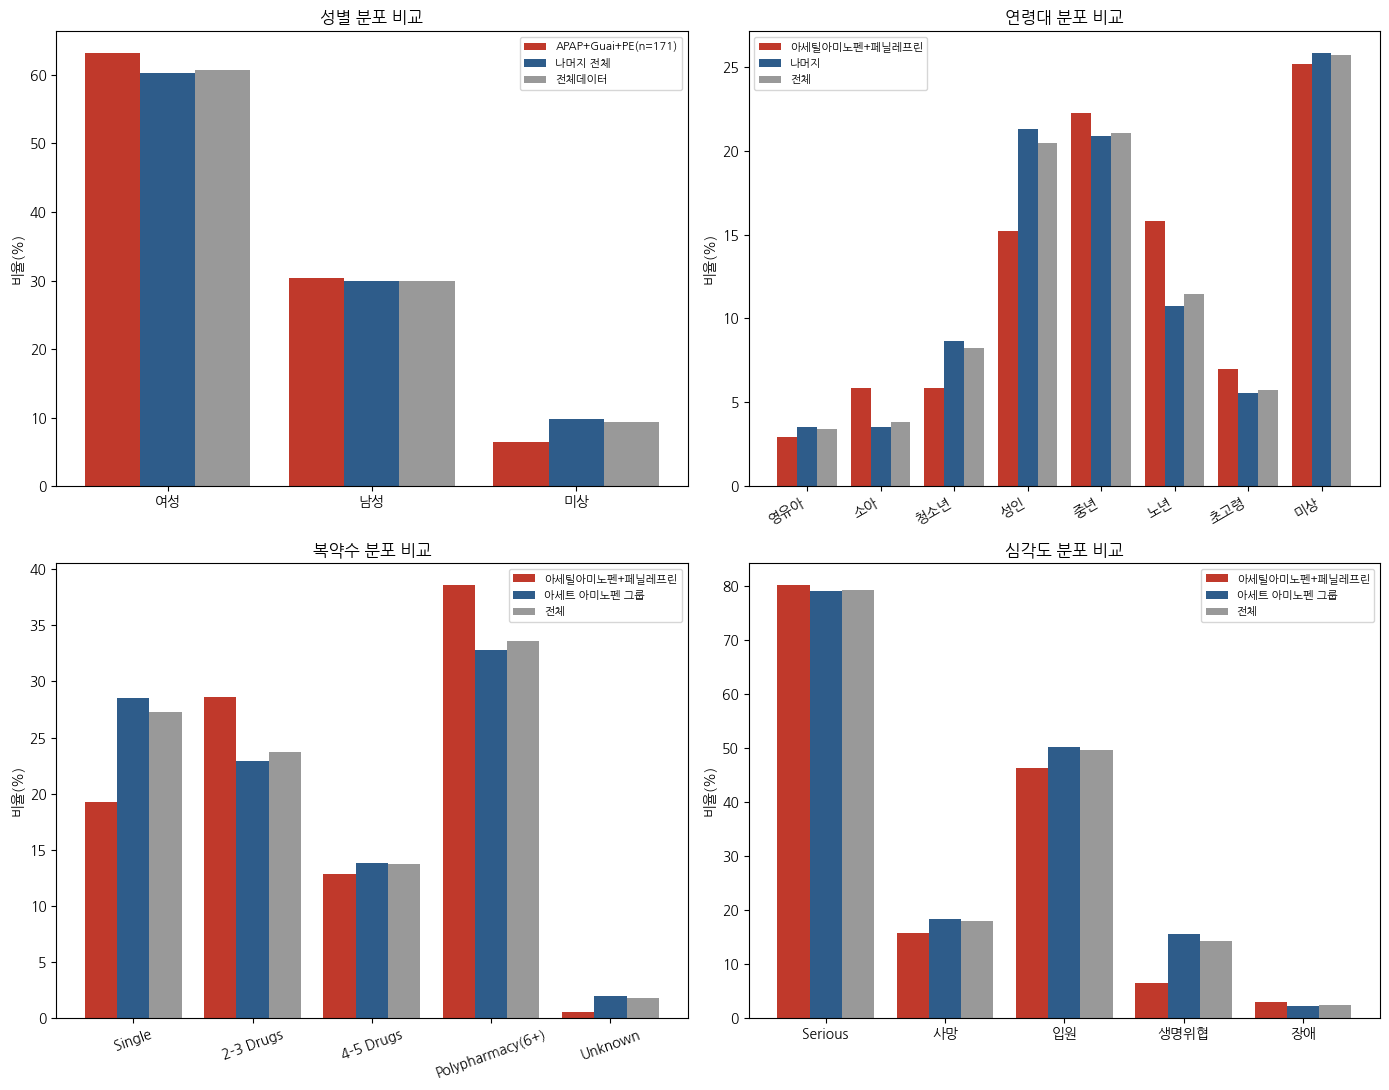

In [8]:
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. 성별
order_sex = ["Female","Male","Unknown"]
label_sex = {"Female":"여성","Male":"남성","Unknown":"미상"}
t_pct = target['patient_sex'].value_counts(normalize=True).reindex(order_sex, fill_value=0) * 100
r_pct = rest['patient_sex'].value_counts(normalize=True).reindex(order_sex, fill_value=0) * 100
a_pct = df['patient_sex'].value_counts(normalize=True).reindex(order_sex, fill_value=0) * 100
x = range(len(order_sex)); w = 0.27
ax = axes[0,0]
ax.bar([i-w for i in x], t_pct, width=w, label=f"APAP+Guai+PE(n={len(target)})", color="#C0392B")
ax.bar([i for i in x], r_pct, width=w, label="나머지 전체", color="#2E5C8A")
ax.bar([i+w for i in x], a_pct, width=w, label="전체데이터", color="#999999")
ax.set_xticks(list(x)); ax.set_xticklabels([label_sex[o] for o in order_sex])
ax.set_ylabel("비율(%)"); ax.set_title("성별 분포 비교"); ax.legend(fontsize=8)

# 2. 연령대
order_age = ["Infant(0-2)","Child(3-12)","Teen(13-18)","Adult(19-40)","Middle-Aged(41-65)","Senior(66-80)","Elderly(81+)","Unknown"]
label_age = {"Infant(0-2)":"영유아","Child(3-12)":"소아","Teen(13-18)":"청소년","Adult(19-40)":"성인",
             "Middle-Aged(41-65)":"중년","Senior(66-80)":"노년","Elderly(81+)":"초고령","Unknown":"미상"}
t_pct = target['age_group'].value_counts(normalize=True).reindex(order_age, fill_value=0) * 100
r_pct = rest['age_group'].value_counts(normalize=True).reindex(order_age, fill_value=0) * 100
a_pct = df['age_group'].value_counts(normalize=True).reindex(order_age, fill_value=0) * 100
x = range(len(order_age)); w = 0.27
ax = axes[0,1]
ax.bar([i-w for i in x], t_pct, width=w, label="아세틸아미노펜+페닐레프린", color="#C0392B")
ax.bar([i for i in x], r_pct, width=w, label="나머지", color="#2E5C8A")
ax.bar([i+w for i in x], a_pct, width=w, label="전체", color="#999999")
ax.set_xticks(list(x)); ax.set_xticklabels([label_age[o] for o in order_age], rotation=30, ha='right')
ax.set_ylabel("비율(%)"); ax.set_title("연령대 분포 비교"); ax.legend(fontsize=8)

# 3. 복약수
order_drug = ["Single","2-3 Drugs","4-5 Drugs","Polypharmacy(6+)","Unknown"]
t_pct = target['drug_count_category'].value_counts(normalize=True).reindex(order_drug, fill_value=0) * 100
r_pct = rest['drug_count_category'].value_counts(normalize=True).reindex(order_drug, fill_value=0) * 100
a_pct = df['drug_count_category'].value_counts(normalize=True).reindex(order_drug, fill_value=0) * 100
x = range(len(order_drug)); w = 0.27
ax = axes[1,0]
ax.bar([i-w for i in x], t_pct, width=w, label="아세틸아미노펜+페닐레프린", color="#C0392B")
ax.bar([i for i in x], r_pct, width=w, label="아세트 아미노펜 그룹", color="#2E5C8A")
ax.bar([i+w for i in x], a_pct, width=w, label="전체", color="#999999")
ax.set_xticks(list(x)); ax.set_xticklabels(order_drug, rotation=20)
ax.set_ylabel("비율(%)"); ax.set_title("복약수 분포 비교"); ax.legend(fontsize=8)

# 4. 심각도
def sev_pct(d):
    return [
        (d['serious']=='Yes').mean()*100,
        d['is_fatal'].mean()*100,
        d['is_hospitalized'].mean()*100,
        d['is_life_threat'].mean()*100,
        d['is_disabling'].mean()*100,
    ]
sev_labels = ["Serious","사망","입원","생명위협","장애"]
t_v, r_v, a_v = sev_pct(target), sev_pct(rest), sev_pct(df)
x = range(len(sev_labels)); w = 0.27
ax = axes[1,1]
ax.bar([i-w for i in x], t_v, width=w, label="아세틸아미노펜+페닐레프린", color="#C0392B")
ax.bar([i for i in x], r_v, width=w, label="아세트 아미노펜 그룹", color="#2E5C8A")
ax.bar([i+w for i in x], a_v, width=w, label="전체", color="#999999")
ax.set_xticks(list(x)); ax.set_xticklabels(sev_labels)
ax.set_ylabel("비율(%)"); ax.set_title("심각도 분포 비교"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

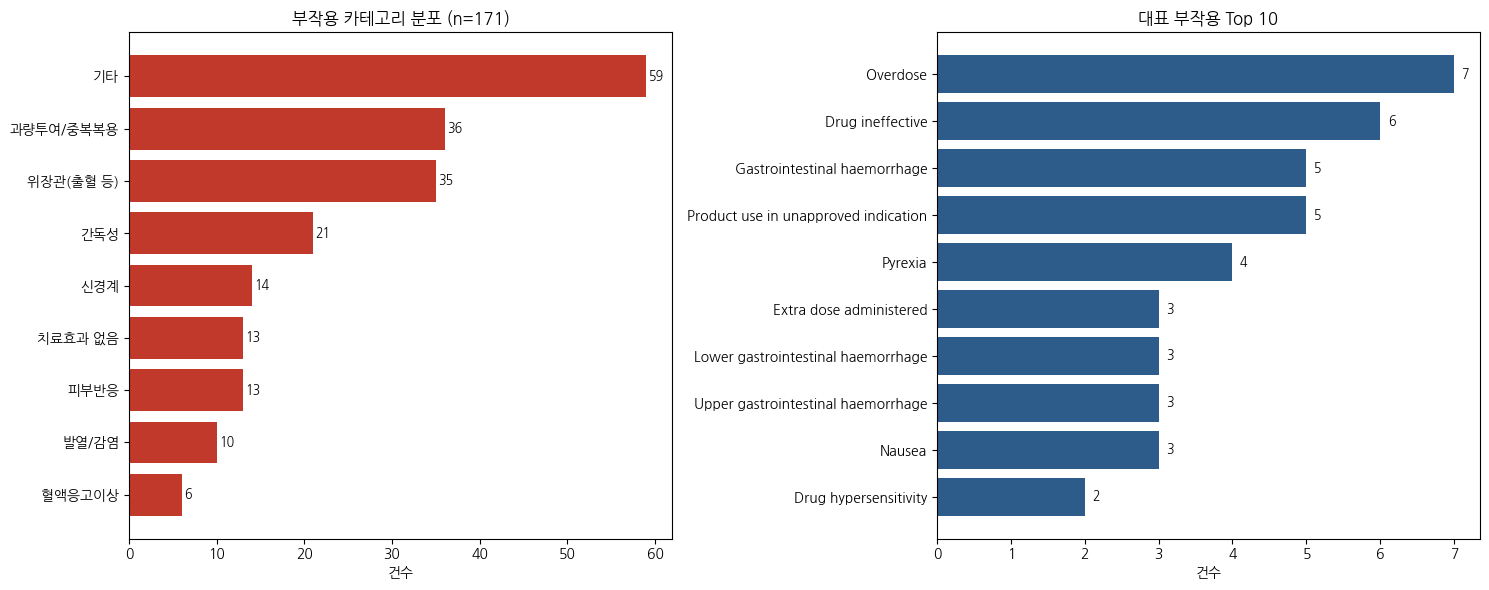

=== 카테고리별 Fisher's exact (target vs rest) ===
과량투여/중복복용       target=36/171(21.1%) rest=381/1077(35.4%) OR=0.49 p=0.0002 **
위장관(출혈 등)       target=35/171(20.5%) rest=111/1077(10.3%) OR=2.24 p=0.0003 **
간독성             target=21/171(12.3%) rest=213/1077(19.8%) OR=0.57 p=0.0200 *
피부반응            target=13/171(7.6%) rest=35/1077(3.2%) OR=2.45 p=0.0159 *
치료효과 없음         target=13/171(7.6%) rest=91/1077(8.4%) OR=0.89 p=0.8814 
발열/감염           target=10/171(5.8%) rest=40/1077(3.7%) OR=1.61 p=0.2050 
신경계             target=14/171(8.2%) rest=59/1077(5.5%) OR=1.54 p=0.1616 
혈액응고이상          target=6/171(3.5%) rest=15/1077(1.4%) OR=2.57 p=0.0560 


In [9]:

CATS = {
    "과량투여/중복복용": ['overdose','extra dose administered','product use in unapproved indication','toxicity to various agents'],
    "위장관(출혈 등)": ['gastrointestinal haemorrhage','nausea','vomiting','abdominal','diarrhoea'],
    "간독성": ['hepatic','liver injury','transaminases'],
    "피부반응": ['toxic epidermal necrolysis','drug eruption','rash','urticaria','pemphigus'],
    "치료효과 없음": ['drug ineffective'],
    "발열/감염": ['pyrexia','infection'],
    "신경계": ['somnolence','presyncope','dizziness','headache','syncope'],
    "혈액응고이상": ['prothrombin time prolonged','anaemia'],
}

def categorize(reactions_str):
    if pd.isna(reactions_str): return set()
    r = reactions_str.lower()
    hit = {cat for cat, keys in CATS.items() if any(k in r for k in keys)}
    return hit or {"기타"}

target_cats = target['reactions'].apply(categorize)
rest_cats = rest['reactions'].apply(categorize)

cat_counts = {}
for s in target_cats:
    for c in s:
        cat_counts[c] = cat_counts.get(c, 0) + 1
cats = pd.Series(cat_counts).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(cats.index, cats.values, color="#C0392B")
axes[0].set_xlabel("건수"); axes[0].set_title(f"부작용 카테고리 분포 (n={len(target)})")
for i, (k, v) in enumerate(cats.items()):
    axes[0].text(v+0.3, i, str(v), va='center', fontsize=9)

top = target['primary_reaction'].value_counts().head(10)
axes[1].barh(top.index[::-1], top.values[::-1], color="#2E5C8A")
axes[1].set_xlabel("건수"); axes[1].set_title("대표 부작용 Top 10")
for i, (k, v) in enumerate(zip(top.index[::-1], top.values[::-1])):
    axes[1].text(v+0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Fisher's exact
print("=== 카테고리별 Fisher's exact (target vs rest) ===")
for cat in CATS.keys():
    t_yes = target_cats.apply(lambda s: cat in s).sum()
    r_yes = rest_cats.apply(lambda s: cat in s).sum()
    t_no, r_no = len(target)-t_yes, len(rest)-r_yes
    odds, p = fisher_exact([[t_yes, t_no], [r_yes, r_no]])
    sig = "**" if p<0.01 else ("*" if p<0.05 else "")
    print(f"{cat:15s} target={t_yes}/{len(target)}({t_yes/len(target)*100:.1f}%) "
          f"rest={r_yes}/{len(rest)}({r_yes/len(rest)*100:.1f}%) OR={odds:.2f} p={p:.4f} {sig}")

In [10]:
def has_gi(r):
    return 'gastrointestinal haemorrhage' in r.lower() if pd.notna(r) else False

df['gi_bleed'] = df['reactions'].apply(has_gi)
df['is_senior_plus'] = df['age_group'].isin(['Senior(66-80)','Elderly(81+)'])

for age_flag, label in [(True, "66세 이상"), (False, "66세 미만")]:
    sub_t = df[(df['is_target_combo']) & (df['is_senior_plus']==age_flag)]
    sub_r = df[(~df['is_target_combo']) & (df['is_senior_plus']==age_flag)]
    t_gi, t_n = sub_t['gi_bleed'].sum(), len(sub_t)
    r_gi, r_n = sub_r['gi_bleed'].sum(), len(sub_r)
    odds, p = fisher_exact([[t_gi, t_n-t_gi], [r_gi, r_n-r_gi]])
    print(f"[{label}] target={t_gi}/{t_n}({t_gi/t_n*100:.1f}%) rest={r_gi}/{r_n}({r_gi/r_n*100:.1f}%) OR={odds:.2f} p={p:.4f}")

[66세 이상] target=12/39(30.8%) rest=5/176(2.8%) OR=15.20 p=0.0000
[66세 미만] target=5/132(3.8%) rest=5/901(0.6%) OR=7.06 p=0.0047


In [11]:
def has_kw(r, keys):
    if pd.isna(r):
        return False
    r = r.lower()
    return any(k in r for k in keys)

target = df[df["is_target_combo"]].copy()

target['gi'] = target['reactions'].apply(lambda r: has_kw(r, ['gastrointestinal haemorrhage','nausea','vomiting','abdominal','diarrhoea']))
target['hepato'] = target['reactions'].apply(lambda r: has_kw(r, ['hepatic','liver injury','transaminases']))
target['skin'] = target['reactions'].apply(lambda r: has_kw(r, ['toxic epidermal necrolysis','drug eruption','rash','urticaria','pemphigus']))
target['age66'] = target['age_group'].isin(['Senior(66-80)','Elderly(81+)'])
target['polypharm'] = target['drug_count_category'] == 'Polypharmacy(6+)'

print("GI:", target['gi'].sum(), "간독성:", target['hepato'].sum(), "피부:", target['skin'].sum())

GI: 35 간독성: 21 피부: 13


In [12]:

sev_cols = {'serious':'Serious(Yes)','is_fatal':'사망','is_hospitalized':'입원',
            'is_life_threat':'생명위협','is_disabling':'장애'}

for cat_col, cat_name in [('gi','위장관'), ('hepato','간독성'), ('skin','피부반응')]:
    print(f"\n--- {cat_name} ---")
    has = target[target[cat_col]]
    nothas = target[~target[cat_col]]
    for col, name in sev_cols.items():
        if col == 'serious':
            h = (has[col]=='Yes').sum(); n_h = (nothas[col]=='Yes').sum()
        else:
            h = has[col].sum(); n_h = nothas[col].sum()
        h_n, nh_n = len(has), len(nothas)
        odds, p = fisher_exact([[h, h_n-h], [n_h, nh_n-n_h]])
        sig = "**" if p<0.01 else ("*" if p<0.05 else "")
        print(f"  {name}: 보유군 {h}/{h_n}({h/h_n*100:.1f}%) vs 비보유군 {n_h}/{nh_n}({n_h/nh_n*100:.1f}%)  OR={odds:.2f} p={p:.4f} {sig}")


--- 위장관 ---
  Serious(Yes): 보유군 32/35(91.4%) vs 비보유군 105/136(77.2%)  OR=3.15 p=0.0938 
  사망: 보유군 6/35(17.1%) vs 비보유군 21/136(15.4%)  OR=1.13 p=0.7977 
  입원: 보유군 25/35(71.4%) vs 비보유군 54/136(39.7%)  OR=3.80 p=0.0011 **
  생명위협: 보유군 1/35(2.9%) vs 비보유군 10/136(7.4%)  OR=0.37 p=0.4644 
  장애: 보유군 0/35(0.0%) vs 비보유군 5/136(3.7%)  OR=0.00 p=0.5846 

--- 간독성 ---
  Serious(Yes): 보유군 21/21(100.0%) vs 비보유군 116/150(77.3%)  OR=inf p=0.0088 **
  사망: 보유군 6/21(28.6%) vs 비보유군 21/150(14.0%)  OR=2.46 p=0.1079 
  입원: 보유군 14/21(66.7%) vs 비보유군 65/150(43.3%)  OR=2.62 p=0.0608 
  생명위협: 보유군 3/21(14.3%) vs 비보유군 8/150(5.3%)  OR=2.96 p=0.1377 
  장애: 보유군 1/21(4.8%) vs 비보유군 4/150(2.7%)  OR=1.82 p=0.4849 

--- 피부반응 ---
  Serious(Yes): 보유군 12/13(92.3%) vs 비보유군 125/158(79.1%)  OR=3.17 p=0.4687 
  사망: 보유군 2/13(15.4%) vs 비보유군 25/158(15.8%)  OR=0.97 p=1.0000 
  입원: 보유군 8/13(61.5%) vs 비보유군 71/158(44.9%)  OR=1.96 p=0.2649 
  생명위협: 보유군 2/13(15.4%) vs 비보유군 9/158(5.7%)  OR=3.01 p=0.1985 
  장애: 보유군 1/13(7.7%) vs 비보유군 4/158(2.5%)  

In [13]:
target['suicide_related'] = (
    target['drug_indication'].isin(['Suicide Attempt','Suspected Suicide']) |
    target['reactions'].str.contains('overdose|intentional', case=False, na=False)
)

h = target[target['hepato']]['suicide_related'].sum()
nh = target[~target['hepato']]['suicide_related'].sum()
hn, nhn = target['hepato'].sum(), (~target['hepato']).sum()
odds, p = fisher_exact([[h, hn-h], [nh, nhn-nh]])
print(f"간독성군 자살/과량투여 연관: {h}/{hn}({h/hn*100:.1f}%) vs 비간독성군 {nh}/{nhn}({nh/nhn*100:.1f}%) OR={odds:.2f} p={p:.4f}")

간독성군 자살/과량투여 연관: 9/21(42.9%) vs 비간독성군 19/150(12.7%) OR=5.17 p=0.0018


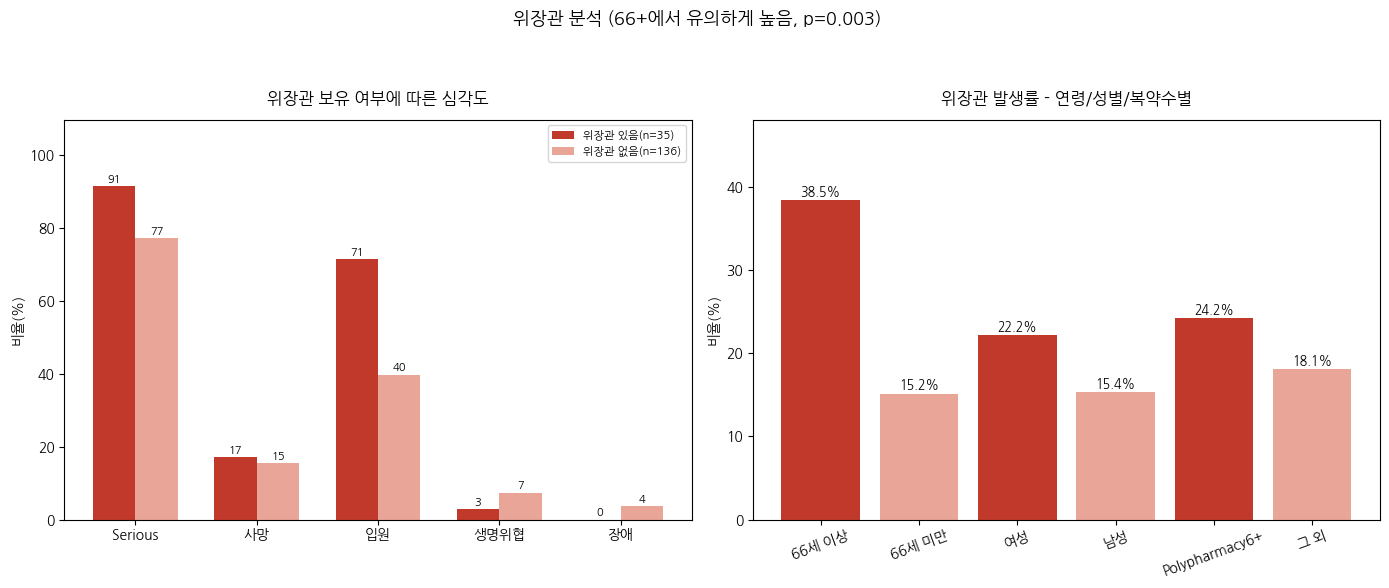

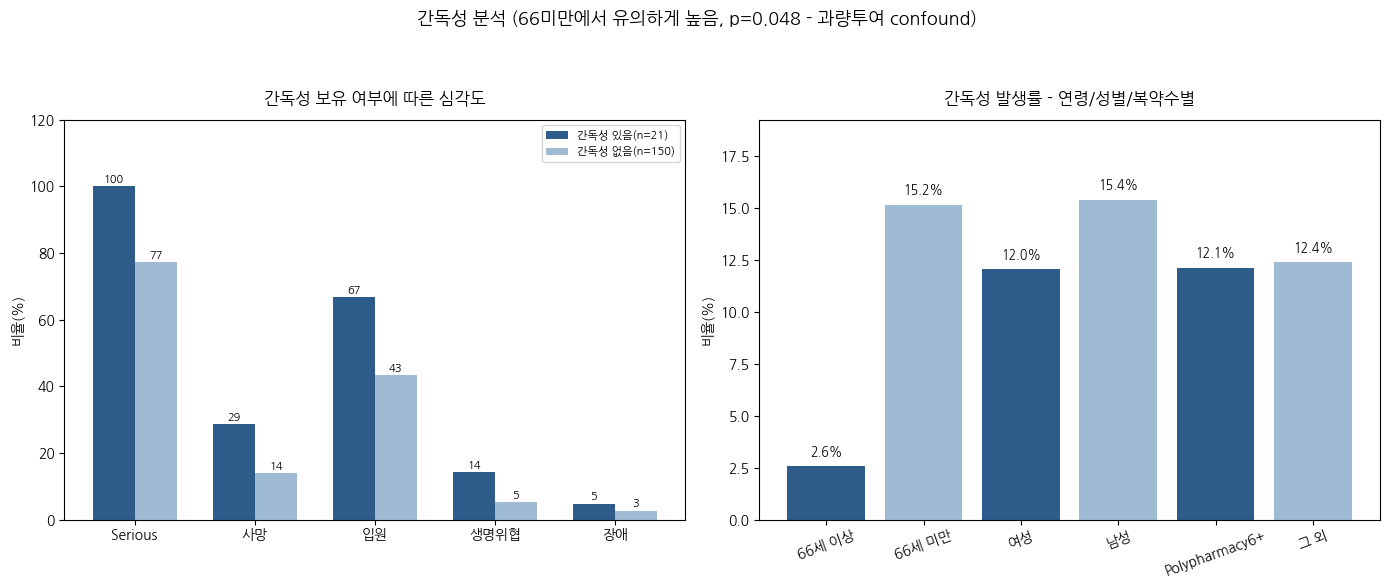

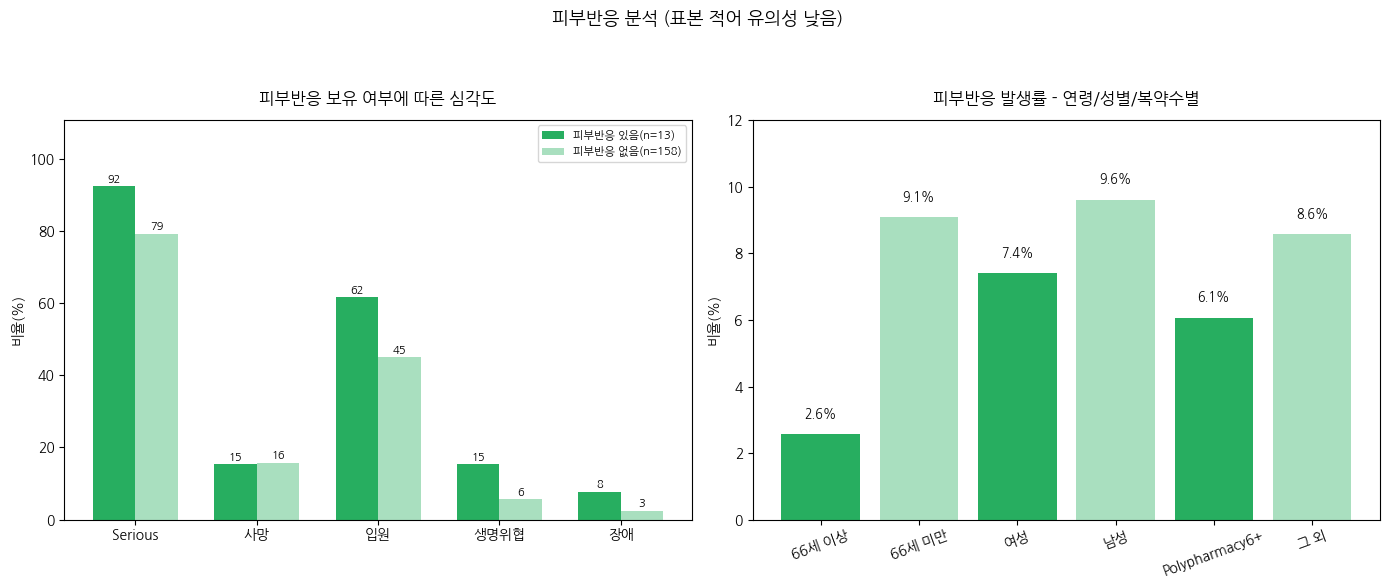

In [14]:
plt.rcParams['axes.unicode_minus'] = False

def make_chart(cat_col, cat_name, color_main, color_sub, extra_note=""):
    has = target[target[cat_col]]
    nothas = target[~target[cat_col]]
    n_has, n_not = len(has), len(nothas)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # 왼쪽: 심각도 5항목 (있음 vs 없음)
    sev_labels = ['Serious', '사망', '입원', '생명위협', '장애']

    def sevs(d):
        return [
            (d['serious'] == 'Yes').mean() * 100,
            d['is_fatal'].mean() * 100,
            d['is_hospitalized'].mean() * 100,
            d['is_life_threat'].mean() * 100,
            d['is_disabling'].mean() * 100,
        ]

    v_has, v_not = sevs(has), sevs(nothas)
    x = np.arange(len(sev_labels))
    w = 0.35
    ax = axes[0]
    ax.bar(x - w/2, v_has, w, label=f'{cat_name} 있음(n={n_has})', color=color_main)
    ax.bar(x + w/2, v_not, w, label=f'{cat_name} 없음(n={n_not})', color=color_sub)
    ax.set_xticks(x)
    ax.set_xticklabels(sev_labels)
    ax.set_ylabel('비율(%)')
    ax.set_title(f'{cat_name} 보유 여부에 따른 심각도',pad=12)
    ax.set_ylim(0, max(max(v_has), max(v_not))*1.2)
    ax.legend(fontsize=8)
    for i, (a, b) in enumerate(zip(v_has, v_not)):
        ax.text(i - w/2, a + 1, f"{a:.0f}", ha='center', fontsize=8)
        ax.text(i + w/2, b + 1, f"{b:.0f}", ha='center', fontsize=8)

    # 오른쪽: 연령/성별/복약수별 발생률
    sub_labels = ['66세 이상', '66세 미만', '여성', '남성', 'Polypharmacy6+', '그 외']
    g_age_h = target[target['age66']][cat_col].mean() * 100
    g_age_l = target[~target['age66']][cat_col].mean() * 100
    g_f = target[target['patient_sex'] == 'Female'][cat_col].mean() * 100
    g_m = target[target['patient_sex'] == 'Male'][cat_col].mean() * 100
    g_poly = target[target['polypharm']][cat_col].mean() * 100
    g_rest = target[~target['polypharm']][cat_col].mean() * 100
    vals = [g_age_h, g_age_l, g_f, g_m, g_poly, g_rest]
    colors = [color_main, color_sub, color_main, color_sub, color_main, color_sub]

    ax2 = axes[1]
    bars = ax2.bar(sub_labels, vals, color=colors)
    ax2.set_ylabel('비율(%)')
    ax2.set_title(f'{cat_name} 발생률 - 연령/성별/복약수별',pad=12)
    ax2.set_ylim(0, max(vals)*1.25)
    ax2.tick_params(axis='x', rotation=20)
    for b, v in zip(bars, vals):
        ax2.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

    fig.suptitle(f" {cat_name} 분석{extra_note}",
                 fontsize=13, y=1.06)
    plt.tight_layout()
    plt.show()


make_chart('gi', '위장관', '#C0392B', '#E8A598',
           " (66+에서 유의하게 높음, p=0.003)")

make_chart('hepato', '간독성', '#2E5C8A', '#9FBBD4',
           " (66미만에서 유의하게 높음, p=0.048 - 과량투여 confound)")

make_chart('skin', '피부반응', '#27AE60', '#A9DFBF',
           " (표본 적어 유의성 낮음)")

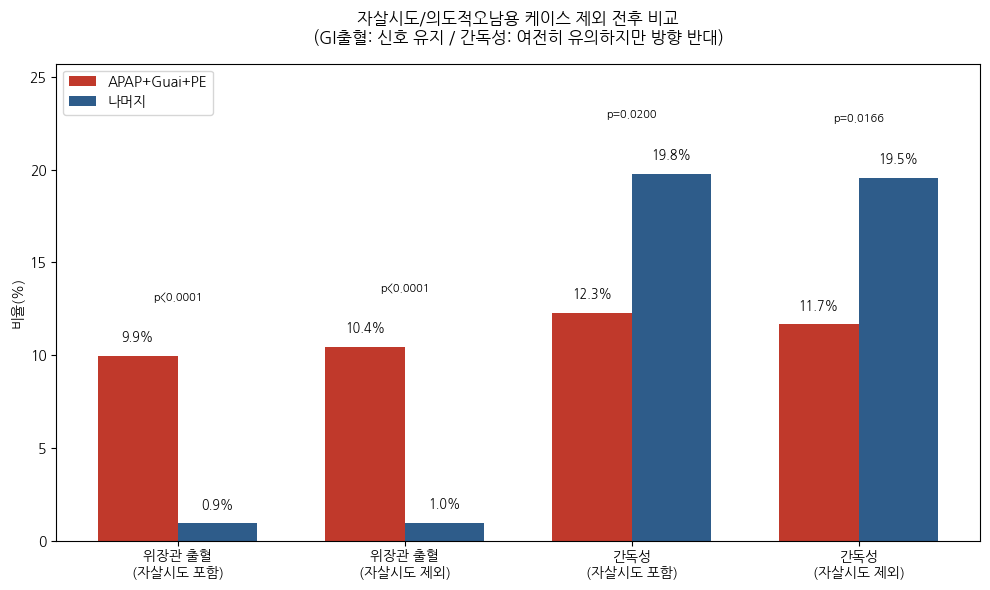

In [15]:
plt.rcParams['axes.unicode_minus'] = False

# 1. 자살시도/의도적 오남용 플래그
selfharm_inds = ['Suspected Suicide','Suicide Attempt','Intentional Product Misuse','Overdose','Intentional Overdose']
df['selfharm'] = df['drug_indication'].isin(selfharm_inds)

def has_gi(r):
    return 'gastrointestinal haemorrhage' in r.lower() if pd.notna(r) else False
def has_hep(r):
    if pd.isna(r): return False
    r = r.lower()
    return any(k in r for k in ['hepatic','liver injury','transaminases'])

df['gi_bleed'] = df['reactions'].apply(has_gi)
df['hepato'] = df['reactions'].apply(has_hep)

# 2. 자살시도 포함 vs 제외 비교표 만들기
def rate_and_p(data, col):
    t = data[data['is_target_combo']]
    r = data[~data['is_target_combo']]
    t_yes, r_yes = t[col].sum(), r[col].sum()
    t_n, r_n = len(t), len(r)
    odds, p = fisher_exact([[t_yes, t_n-t_yes],[r_yes, r_n-r_yes]])
    return t_yes/t_n*100, r_yes/r_n*100, p

df_excl = df[~df['selfharm']]

gi_full_t, gi_full_r, gi_full_p = rate_and_p(df, 'gi_bleed')
gi_excl_t, gi_excl_r, gi_excl_p = rate_and_p(df_excl, 'gi_bleed')
hep_full_t, hep_full_r, hep_full_p = rate_and_p(df, 'hepato')
hep_excl_t, hep_excl_r, hep_excl_p = rate_and_p(df_excl, 'hepato')

labels = ["위장관 출혈\n(자살시도 포함)", "위장관 출혈\n(자살시도 제외)", "간독성\n(자살시도 포함)", "간독성\n(자살시도 제외)"]
target_v = [gi_full_t, gi_excl_t, hep_full_t, hep_excl_t]
rest_v   = [gi_full_r, gi_excl_r, hep_full_r, hep_excl_r]
pvals_v  = [gi_full_p, gi_excl_p, hep_full_p, hep_excl_p]
pvals = {l: (f"p={p:.4f}" if p>=0.0001 else "p<0.0001") for l,p in zip(labels, pvals_v)}

# 3. 시각화
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x-w/2, target_v, w, label='APAP+Guai+PE', color='#C0392B')
ax.bar(x+w/2, rest_v, w, label='나머지', color='#2E5C8A')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('비율(%)')
ax.set_title('자살시도/의도적오남용 케이스 제외 전후 비교\n(GI출혈: 신호 유지 / 간독성: 여전히 유의하지만 방향 반대)', pad=15)
ax.set_ylim(0, max(max(target_v), max(rest_v))*1.3)
ax.legend()
for i, (t, r) in enumerate(zip(target_v, rest_v)):
    ax.text(i-w/2, t+0.8, f"{t:.1f}%", ha='center', fontsize=9)
    ax.text(i+w/2, r+0.8, f"{r:.1f}%", ha='center', fontsize=9)
    ax.text(i, max(t,r)+3, pvals[labels[i]], ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.show()

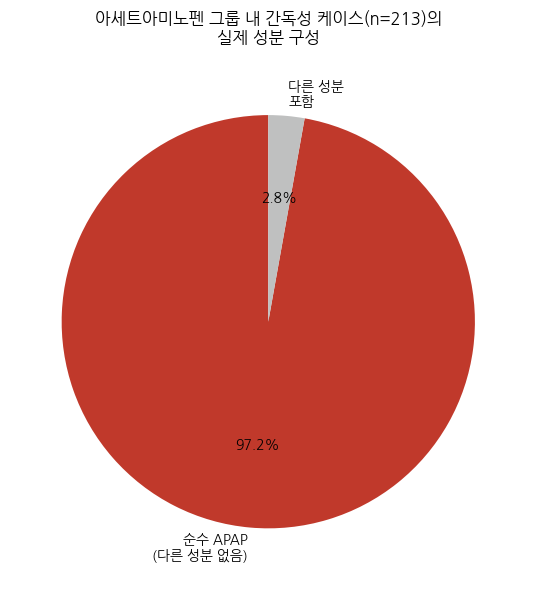

In [16]:
plt.rcParams['axes.unicode_minus'] = False

# 1. 간독성 플래그 및 "나머지" 그룹 추출
def has_hep(r):
    if pd.isna(r):
        return False
    r = r.lower()
    return any(k in r for k in ['hepatic', 'liver injury', 'transaminases'])

df['hepato'] = df['reactions'].apply(has_hep)
rest = df[~df['is_target_combo']]
hep_rest = rest[rest['hepato']].copy()

# 2. 순수 APAP 계열인지 (비-APAP 성분이 전혀 없는지) 판별
def is_pure_apap_family(s):
    if pd.isna(s):
        return False
    s = s.upper()
    non_apap_keywords = ['DIPHENHYDRAMINE', 'PHENYLEPHRINE', 'DEXTROMETHORPHAN',
                          'GUAIFENESIN', 'CHLORPHENIRAMINE', 'ASPIRIN', 'CAFFEINE', 'DOXYLAMINE']
    return not any(k in s for k in non_apap_keywords)

hep_rest['pure_apap_family'] = hep_rest['suspect_drug'].apply(is_pure_apap_family)

pure_pct = hep_rest['pure_apap_family'].mean() * 100
other_pct = 100 - pure_pct

# 3. 파이차트
labels = ['순수 APAP\n(다른 성분 없음)', '다른 성분\n포함']
values = [pure_pct, other_pct]
colors = ['#C0392B', '#BFC0C0']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title(f'아세트아미노펜 그룹 내 간독성 케이스(n={len(hep_rest)})의\n실제 성분 구성', pad=15)

plt.tight_layout()
plt.show()

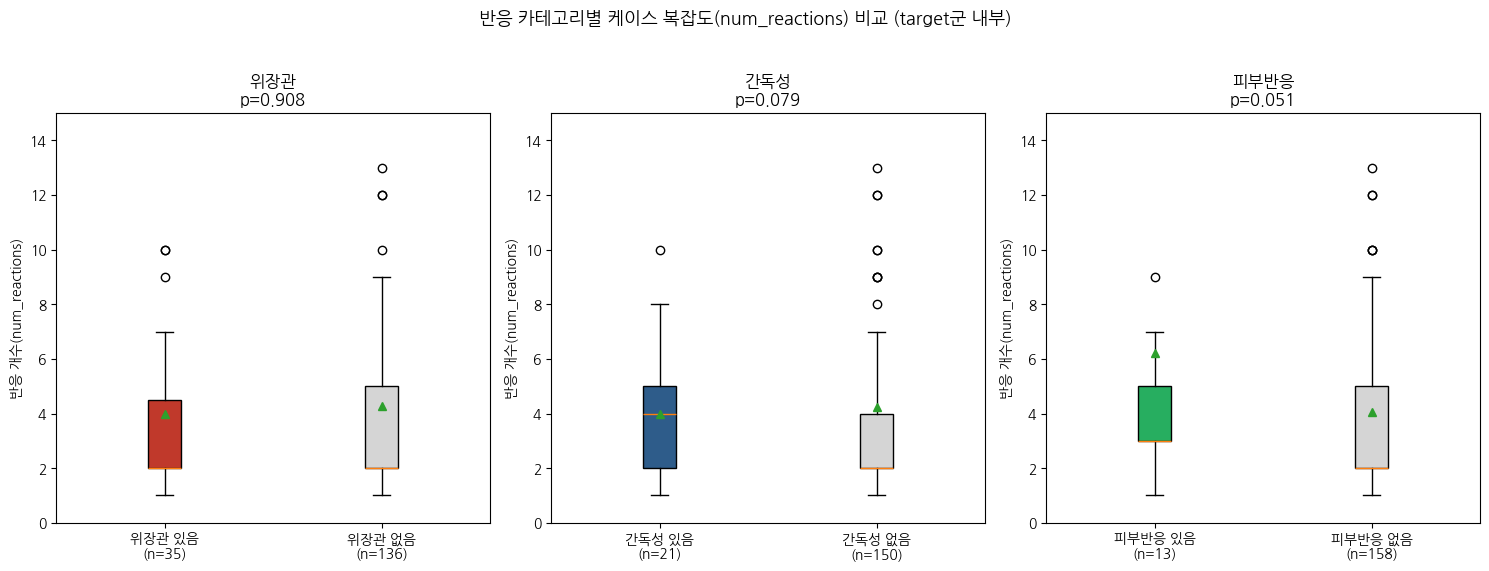

In [17]:

plt.rcParams['axes.unicode_minus'] = False

# 1. 카테고리 플래그 (이미 있다면 생략 가능)
def has_kw(r, keys):
    if pd.isna(r):
        return False
    r = r.lower()
    return any(k in r for k in keys)

target['gi'] = target['reactions'].apply(lambda r: has_kw(r, ['gastrointestinal haemorrhage','nausea','vomiting','abdominal','diarrhoea']))
target['hepato'] = target['reactions'].apply(lambda r: has_kw(r, ['hepatic','liver injury','transaminases']))
target['skin'] = target['reactions'].apply(lambda r: has_kw(r, ['toxic epidermal necrolysis','drug eruption','rash','urticaria','pemphigus']))

# 2. Mann-Whitney U test + 박스플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
specs = [
    ('gi', '위장관', '#C0392B'),
    ('hepato', '간독성', '#2E5C8A'),
    ('skin', '피부반응', '#27AE60'),
]

for ax, (col, name, color) in zip(axes, specs):
    has = target[target[col]]['num_reactions']
    nothas = target[~target[col]]['num_reactions']
    u, p = mannwhitneyu(has, nothas, alternative='two-sided')
    pnote = f"p={p:.3f}"

    bp = ax.boxplot(
        [has, nothas],
        tick_labels=[f'{name} 있음\n(n={len(has)})', f'{name} 없음\n(n={len(nothas)})'],
        patch_artist=True, showmeans=True
    )
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][1].set_facecolor('#D5D5D5')
    ax.set_ylabel('반응 개수(num_reactions)')
    ax.set_title(f'{name}\n{pnote}')
    ax.set_ylim(0, 15)  # 이상치(34) 제외하고 보기 좋게

plt.suptitle('반응 카테고리별 케이스 복잡도(num_reactions) 비교 (target군 내부)', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()